# An Analysis of Whistleblower News Coverage from 2025

### DACSS 611 Intro to Python Final Project, Conor de Leeuw

# Introduction:

This research project aims to analyze which news organizations publish the most articles containing whistleblower-related headlines, and how this coverage has changed over time in 2025. Whistleblowers themselves have become controversial figures today in the American news media space. As powerful forces of exposing wrongdoing and reinforcing government accountability, their behavior is captured throughout a variety of media sources as either positive or neutral. Moreover, whistleblowers have gained overall traction across various journalist outlets from the heroic, selfless character, while other sources capture whistleblowers for their unloyal, brazen attitudes. During spikes of political backlash and ongoing scandals, more news outlets invest their daily coverage in reporting the status of government affairs. Greater coverage can shape public awareness and perception of political issues for citizens, as well as establish trust for them in their news outlet disclose wrongdoing cases. This analysis hopes to not only shed light on the dynamics of media coverage but also helps contextualize public exposure to whistleblower issues this past year.

# Research Question


The research question for this analysis plans to examine which news organizations publish the most whistleblower-related articles in 2025, and how this news coverage has changed over time.

The value of understanding media coverage for whistleblowers is crucial to understanding their role in shaping public perception and perceived affiliation with whistleblower disclosures. More pressure and coverage on whistleblowers can either negatively or positively influence the perception of their case, and provide information on attention patterns and media priorities. Examining trends across major news outlets can help identify which outlets consistenly report on whistleblowers, how coverage fluctuates, and whether there are periods where coverage begins to spike or decline.

The role of media coverage also plays a significant role in instititutional actions regarding whistleblower cases. Increased coverage surrounding disclosure of classified information can circulate higher extremes of public opinion, and channel more partisanship views in political debates. Coverage analysis can help  reveal biases, trends, and gaps in media coverage. This helps illuminate which organizations serve as key sources for the public pertaining to government accountability, and whether media attention aligns with high-profile whistleblower cases.

# Dataset

For this analysis, I will be using Google News RSS HTML URL to scrape whistleblower-related articles (news articles that contain the term "Whistleblowers" in the search term) from a non-tabular format, and collect their headline title, summary, outlet source and date.  

# Data Wrangling
First, I uploaded the packages necessary for creating a dataframe, plot visualizations, content parsing, and dealing with datetime types. Packages that weren't previously imported were included at the beginning using !pip.

In [1]:

!pip install pandas matplotlib seaborn feedparser beautifulsoup4 tldextract


import pandas as pd
import numpy as np
import feedparser
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import tldextract
from datetime import datetime


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 4.8 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=2f43927527c92e125ae724c8f84a7cae7877f6681a602c56f59a922922833e85
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


After navigating to google news, I searched "whistleblowers in the search bar, copied the url, and used feedparser to scrape the url link for entires containing title, summary, date etc. Feed.entries contains all articles in the feed as a list of objects. The length of entries is reported to be 102, meaning that this analysis will be working with a large amount of news outlets reporting on whistleblower cases.

In [2]:
# Scrape Whistleblower articles from google news RSS

rss_url = "https://news.google.com/rss/search?q=whistleblower&hl=en-US&gl=US&ceid=US:en"

feed = feedparser.parse(rss_url)
len(feed.entries)



100

Using the pandas import, the RSS article items are converted to "title" and "link" columns. BeautifulSoup argument is performed to remove extra html and embedded links for clean data parsing and extract summary text. A "published" column is created converting published information in numbers to datetime objects. This is essential for preparing visualizations containing coverage over time in 2025.

Upon viewing the CSV file, all outlets are labelled as "google" instead of their associated news domain. Under the "title" column, all news title contain their news domain at the very end.

In order to best extract news organizations (cnn, AP news, Fox News, Reuters) from title, I used the tldeextract package to extract the full domain name. The entry.source.title function is then used to check if each entry has a source using an if conditional statement. If a source doesn't exist, then Python will output "Unknown" in the outlet column.

In [3]:
# Convert RSS items into Dataframe using Pandas
articles = []

for entry in feed.entries:
    title = entry.title
    link = entry.link

    # Parse summary text
    summary = BeautifulSoup(entry.summary, "html.parser").get_text()   # removes html and embedded links for clean data parsing

    # Publication date normalization
    published = pd.to_datetime(entry.published)

    # Extract news organization using domain
    ext = tldextract.extract(link)
    outlet = outlet = entry.source.title if "source" in entry else "Unknown"
  # using entry.source.title to pull news domain instead of just having outlet say "google". Include entry sources such as cnn, foxnews, nytimes, etc.




In the dataset called articles created from pandas, I used the append function to create a title column that captures the article headline, the google news link, a summary of the article, the date and time of publication and the outlet domain.

For better transparency, I renamed the dataset to news_articles and called .head() to print the first 4 rows as a wrangle check.

In [4]:
 # Append to create title, link, summary, published, and outlet columns
 articles.append({
        "title": title,
        "link": link,
        "summary": summary,
        "published": published,
        "outlet": outlet
    })

 # Rename to news_articles

news_articles = pd.DataFrame(articles)
news_articles.head()

,title,link,summary,published,outlet
0,Whistleblower complaint alleges top DOJ offici...,https://news.google.com/rss/articles/CBMipgFBV...,Whistleblower complaint alleges top DOJ offici...,2025-06-24 07:00:00,ABC News


As part of the data cleaning process, duplicate articles are removed based on their titles. The published column was transformed to only extract the date and exclude the time of publication. dt.to_period extracts only the month of publication, which will be helpful for creating visualizations for monthly coverage trends.

In [5]:
# Data Cleaning

# Remove title duplicates
news_articles = news_articles.drop_duplicates(subset="title")


# Extract only the date and month from published column
news_articles["date"] = news_articles["published"].dt.date
news_articles["month"] = news_articles["published"].dt.to_period("M")

# Call .info
news_articles.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   title      1 non-null      object        
 1   link       1 non-null      object        
 2   summary    1 non-null      object        
 3   published  1 non-null      datetime64[ns]
 4   outlet     1 non-null      object        
 5   date       1 non-null      object        
 6   month      1 non-null      period[M]     
dtypes: datetime64[ns](1), object(5), period[M](1)
memory usage: 188.0+ bytes


In order for no new published whistleblower articles to reappear, the dataset will be saved and downloaded as an .csv as "whistleblower_news". This part of the code is also explained in the preprocessing .ipynb file.

In [7]:
# Import whistleblower_news file from preprocessing ipynb

news_articles = pd.read_csv("whistleblower_news(1).csv")
news_articles.head()



,title,link,summary,published,outlet,date,month
0,Whistleblower warns massive fraud is happening...,https://news.google.com/rss/articles/CBMiwAFBV...,Whistleblower warns massive fraud is happening...,2025-12-12 12:45:36,Fox News,2025-12-12,2025-12
1,Maine whistleblower alleges Minnesota-like fra...,https://news.google.com/rss/articles/CBMiggFBV...,Maine whistleblower alleges Minnesota-like fra...,2025-12-08 23:44:22,NewsNation,2025-12-08,2025-12
2,Maine's Medicaid program bilked out of million...,https://news.google.com/rss/articles/CBMizgFBV...,Maine's Medicaid program bilked out of million...,2025-12-10 19:26:00,New York Post,2025-12-10,2025-12
3,Whistleblower warns massive fraud is happening...,https://news.google.com/rss/articles/CBMi6gFBV...,Whistleblower warns massive fraud is happening...,2025-12-12 14:03:05,MSN,2025-12-12,2025-12
4,Whistleblower exposes massive fraud in Ohio on...,https://news.google.com/rss/articles/CBMiVkFVX...,Whistleblower exposes massive fraud in Ohio on...,2025-12-10 23:48:20,Fox News,2025-12-10,2025-12


# Descriptive Statistics
For describing the wrangled dataset, the following objects were printed:
, the date range of articles

1.   total number of news articles (len)
2.   date range of articles published in this dataset (.min and .max)

1.  Top 10 outlets that have the most whistleblower coverage (.value_counts)
2.  total sum of missing values (.isna)





In [8]:
# Descriptive Statistics
print("Total articles:", len(news_articles))
print("Date range:", news_articles['date'].min(), "→", news_articles['date'].max())
print("\nTop outlets:\n", news_articles['outlet'].value_counts().head(10))
print("\nMissing values:\n", news_articles.isna().sum())



Total articles: 100
Date range: 2025-01-14 → 2025-12-12

Top outlets:
 outlet
Reuters                7
Euractiv               3
NewsNation             3
Whistleblower Aid      3
AP News                3
Grassley.senate.gov    3
ABC News               2
Fox News               2
New York Post          2
thehill.com            2
Name: count, dtype: int64

Missing values:
 title        0
link         0
summary      0
published    0
outlet       0
date         0
month        0
dtype: int64


## Interpretation
Between January 14th, 2025 and December 11, 2025, there are a total of 102 whistleblower related articles that have been released by media sources. Reuters currently has released the most articles covering whistleblowers (7 articles), with Euractiv, NewsNation, Whistleblower Aid, Grassley.Senate.gov reporting 3 articles each.

More mainstream, national new sources, such as ABC, Fox News, and the New York Post have reported 2 articles this year covering whistleblowers.

There are no missing values to report from the dataset.

# Data Visualizations


The following 5 visualizations each display either a univariate, bivariate or multivariate relationship between news outlets and article coverage over 2025. The first plot portrays a single variable distribution of articles by outlet domain. The second plot is a time series plot that represents whistleblower articles over time. The third plot is a bivariate relationship displaying the frequency of each of the top 10 news outlets article publication. The fourth plot displays a multivariate relationship using a grouped bar plot to show monthly distribution of news articles by the top 8 news outlets. The fifth plot displays the 7-day moving average of whistleblower articles that are published.

## Plot 1: Single Variable Bar Chart

To capture a single variable distribution of article count, Plot 1 uses a bar graph to show the overall count of whistleblower articles in 2025 by news outlets. Because there were 100+ news outlets collected during the wrangling process, only the top 15 are shown to highlight which media sources are the most active in covering whistleblower stories.  

The goal of this visualization is to interpret which outlets cover the most attention surrounding whistleblower cases.

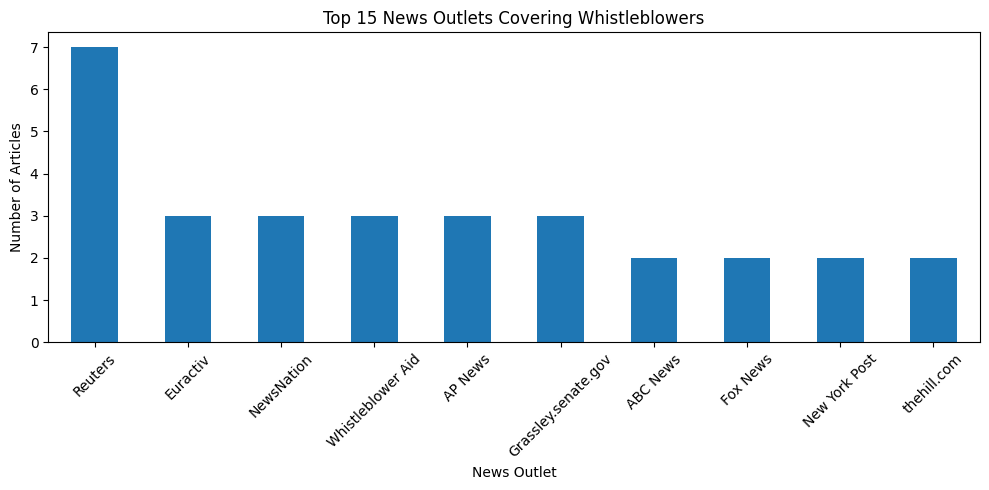

In [9]:
# Plot 1: Single Variable Distribution:
        # Distribution of Articles by outlet domain

plt.figure(figsize=(10,5))
news_articles['outlet'].value_counts().head(10).plot(kind='bar')
plt.title("Top 15 News Outlets Covering Whistleblowers")
plt.xlabel("News Outlet")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Based on the bar chart, it shows that Reuters has published the most articles in 2025 relating to whistleblower cases (7 articles), while both Euractiv, NewsNation, Whistleblower Aid, AP News, Grassley.senate.gov have covered 3 articles. Less mainstream, and more politically oriented news outlets tend to have higher coverage regarding whistleblowers. In comparsion to more mainstream, widely-accessible news outlets like ABC and Fox News, more global-based outlets like Reuters play a central role in shaping public visbility surrounding whistleblowers

## Plot 2: Line Plot of Frequency of Whistleblower Articles

In order to capture the frequency of articles over time, I pulled "date" into the x-axis, and "article count" to help identify areas of spikes and declines in media coverage. Daily_counts was made to create a series where the index is each date and the value is the number of articles published on that day. A line plot was chosen to represent the changes day by day.

The overall goal of this visual is to map how whistleblower coverage fluctates over time on a daily basis. A line plot will help see spikes and declines, see if reporting is irregular or consistent, and understand short-term patterns that a monthly averages might not show.

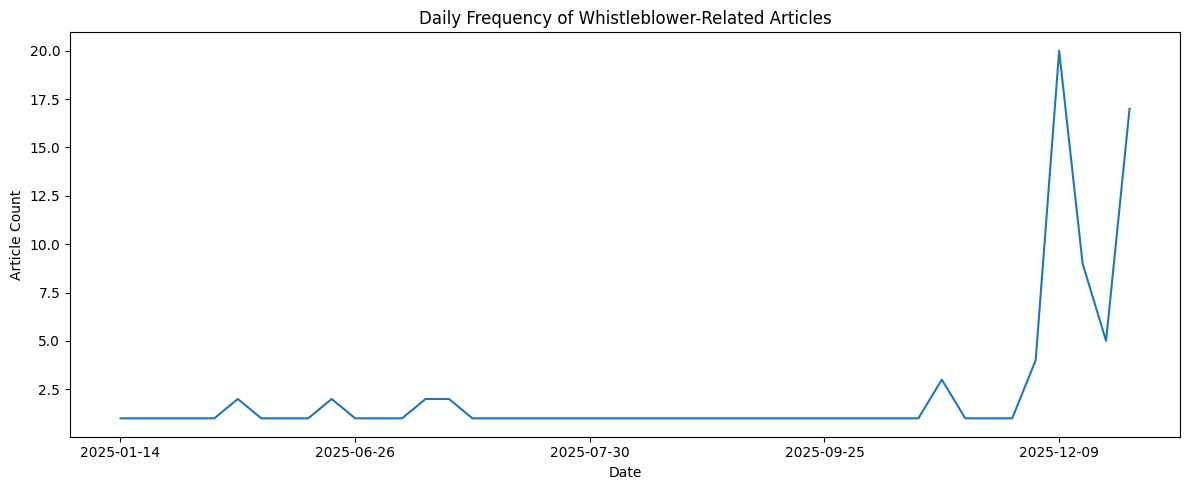

In [16]:
# Plot 2: Articles Over Time (Time Component)

daily_counts = news_articles.groupby("date").size()

plt.figure(figsize=(12,5))
daily_counts.plot()
plt.title("Daily Frequency of Whistleblower-Related Articles")
plt.xlabel("Date")
plt.ylabel("Article Count")
plt.tight_layout()
plt.show()


Based on the graph, general spikes in whistleblower coverage during the first half of the year occurred approximately around every 3-4 months. During the summer months, whistleblower coverage was at an all-time low with essentially zero articles published from any media outlet. However, in the past week, there has been a drastic spike in published whistleblower articles (reaching to 20) either due to shared circulation of new whistleblower cases or emerging classified information that has been leaked.

### Plot 3: Heatmap of Article Publication by Month for Top 10 News Outlets (Bivariate)

To compare article publication count by the top 10 news outlet over months, I used a heatmap to visually see this bivariate relationship. To find the top 10 news articles, I pulled from news_articles and used the .head() function to extract the top 10 articles from the dataset, and filtered these articles by their outlet.  

Using the monthly_outlet object, I pivoted the data from long to wide format, making the rows = outlet, columns = months, and values = number of articles. I used sns.heatmap and coded each cell's color to represent the articles frequency (using Google Colab seaborn default colors).

The goal of the heatmap is to visualize the intensity of news coverage over time, and identify which news outlets were the most active by month. The heatmap also shows how reporting patterns differ across organizations, and which months had spikes and declines in coverage.

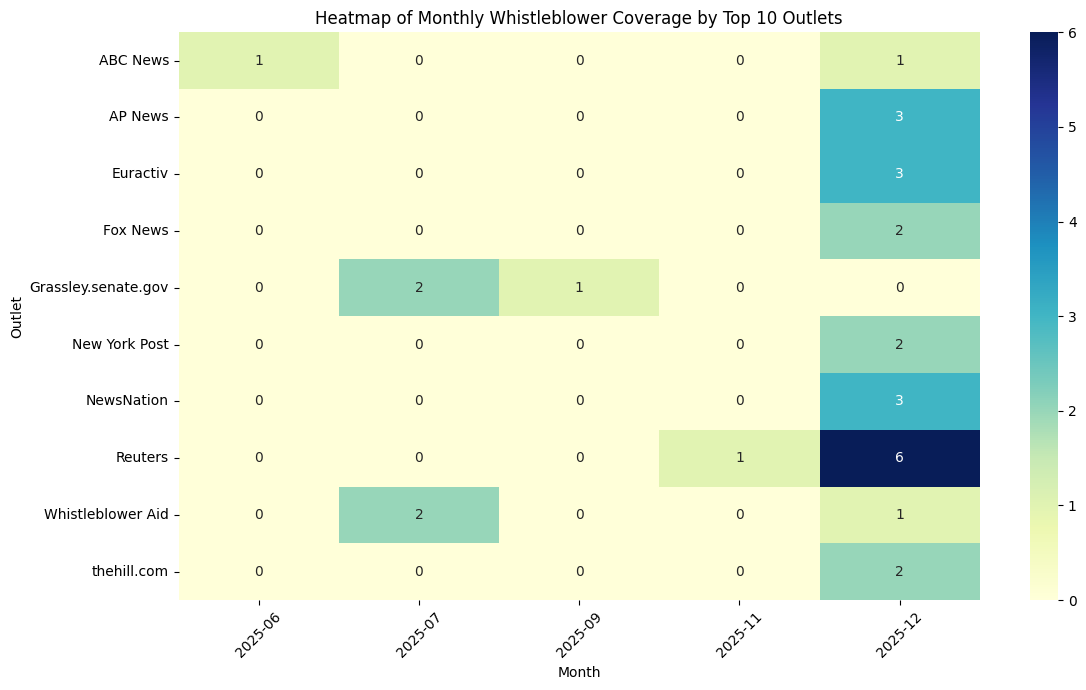

In [13]:
# Plot 3: Outlet vs. Frequency over Time for Top 10 Outlets (Bivariate Relationship)

# Find top 10 outlets by total article count
top_outlets = news_articles['outlet'].value_counts().head(10).index

# Filter to just outlets
filtered = news_articles[news_articles['outlet'].isin(top_outlets)]

# Count articles per outlet per month
monthly_outlet = (
    filtered.groupby(["month", "outlet"])
    .size()
    .reset_index(name="count")
)



monthly_pivot = monthly_outlet.pivot(
    index="outlet",
    columns="month",
    values="count"
).fillna(0)

plt.figure(figsize=(12,7))
sns.heatmap(monthly_pivot, annot=True, fmt='g', cmap="YlGnBu") # annot = True to print the actual values in the cells
plt.title("Heatmap of Monthly Whistleblower Coverage by Top 10 Outlets")
plt.ylabel("Outlet")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





Based on the heatmap, the intensity of media coverage around whistleblowers has been the most concentrated during December 2025 (most likely ongoing). All the other months seem to have very few whistleblower coverage, either due to lack of disclosure cases, or the recent rise of more public sector employees exposing wrongdoing.

## Plot 4: Grouped Bar Plot of Media Coverage Distribution for Top 10 Outlets by Grouping Date and Count (Multivariate Graph)

Using date and count of articles published, a grouped bar plot will be used to see how distribution varies by month in 2025.

Value_counts is used to take article account for the first 10 articles in the dataset using .head(10). Index helps to extract the actual outlet names themselves into an object.

Group_by filters only the month and the outlet. Reset_index is used to create a smaller dataframe that has a column "Count".

Originally, the graph displayed date as MM-YYYY format. For readibility and understanding purposes, I altered this format to just include the name of the month. Using pandas datetime, I converted the "YYYY-MM" format to datetime. Datetime is then converted to month name using string format time. Month_name column is then created with just character "January","February", "March", "April", "May".


The grouped bar plot will help reveal whether coverage is consistent over the year, or driven by specific months. Although article counts reveal which news outlet report the most, the grouped bar plot can show a multivariate approach that show monthly coverage patterns for each outlet.

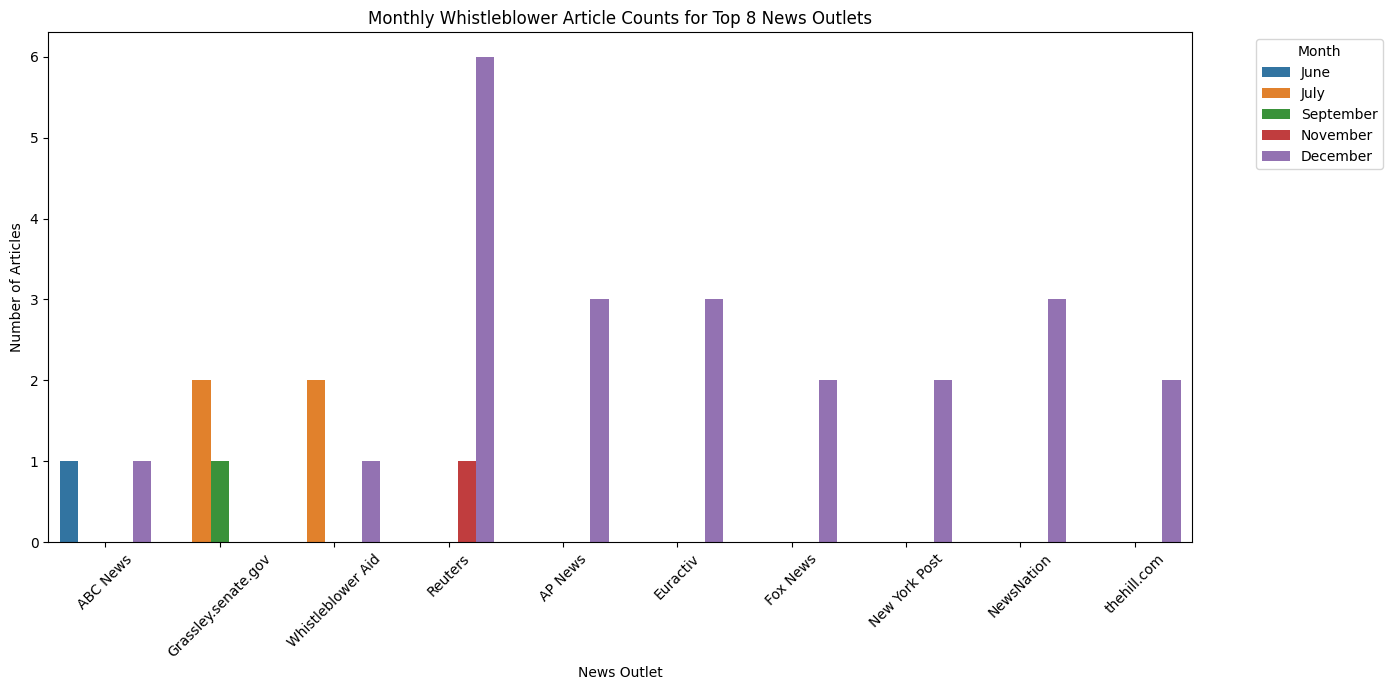

In [14]:
# Plot 4: Grouped bar plot: Distribution of Whistleblower Coverage for the Top 10 Outlets and grouping date and count (Multivariate)

# Identify top 10 outlets by total article count
top_outlets = news_articles['outlet'].value_counts().head(10).index

# Filter to those outlets
filtered = news_articles[news_articles['outlet'].isin(top_outlets)]

# Aggregate: count articles per outlet per month
monthly_outlet = (
    filtered.groupby(["month", "outlet"])
    .size()
    .reset_index(name="count")
)

# Recode month-year to just the month name
# If month column is in "YYYY-MM" string format, convert to datetime first
monthly_outlet['month'] = pd.to_datetime(monthly_outlet['month'], format="%Y-%m")

# Convert datetime to month name
monthly_outlet['month_name'] = monthly_outlet['month'].dt.strftime("%B")
monthly_outlet["month"] = pd.to_datetime(monthly_outlet["month"], errors="coerce")
monthly_outlet["month"] = monthly_outlet["month"].dt.month_name()

plt.figure(figsize=(14,7))
sns.barplot(
    data=monthly_outlet,
    x="outlet",
    y="count",
    hue="month"
)

plt.title("Monthly Whistleblower Article Counts for Top 10 News Outlets")
plt.xlabel("News Outlet")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.legend(title="Month", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




Result of this graph shows similiarity to the heatmap visualization in terms of news coverage by outlet. In July, Grassleysenate.gov and Whistleblower Aid reported more whistleblower articles compared to any other news source. Most of the top 10 news outlets have just begun to publish whistleblower articles this month, highlighting a potential whistleblower case that is gaining more public visbility.

## Plot 5: Line Plot of 7-Day Average of Whistleblower Coverage in 2025

The final plot used will be a 7-day moving average line plot in order to reveal the trend in media attention over time. Instead of covering daily fluctations, this graph helps identify more broader patterns and see if there are any observable sustained increases during major whistleblower revelations.

Daily_counts was used from Plot 2 with .rolling added on to represent the 7-day rolling window for the data. .Mean() calculates the average number of articles published in that 7-day window and assigns it to the "trend" object. "Trend" is assigned to a line plot to visualize the overall weekly average.



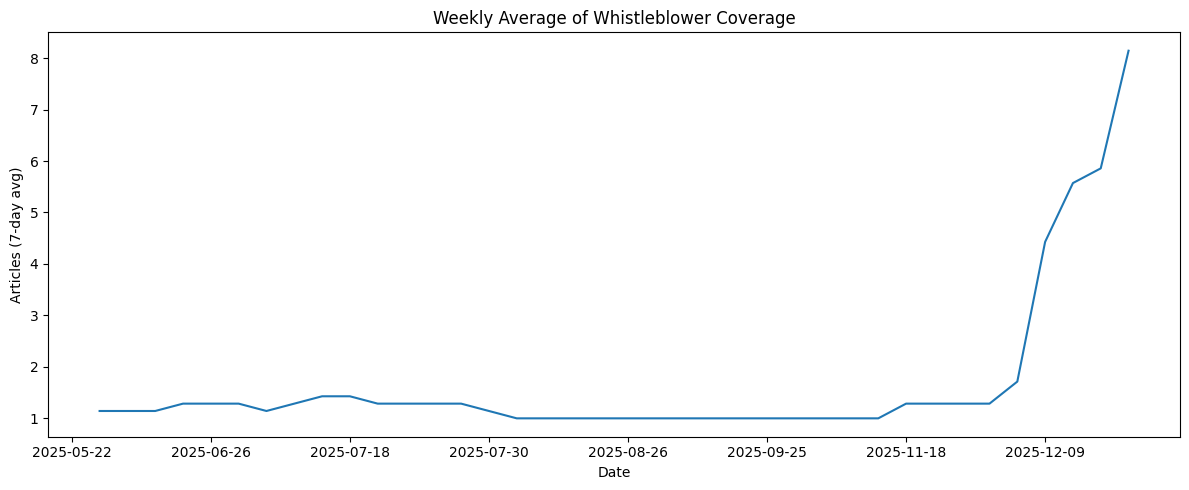

In [18]:
# Plot 5: 7 - Day Average of Whistleblower Coverage in the News

trend = daily_counts.rolling(window=7).mean()

plt.figure(figsize=(12,5))
trend.plot()
plt.title("Weekly Average of Whistleblower Coverage")
plt.xlabel("Date")
plt.ylabel("Articles (7-day avg)")
plt.tight_layout()
plt.show()


# Linear Regression Analysis

In [19]:
# Linear Regression for change over time by month Analysis using descriptive stats
import pandas as pd
import statsmodels.api as sm

# If month is a datetime, convert to numeric month (1-12)
monthly_outlet['month_num'] = monthly_outlet['month'].dt.month

# Create dummy variables for categorical outlet
X = pd.get_dummies(monthly_outlet['outlet'], drop_first=True)

# Include month as a numeric predictor
X['month_num'] = monthly_outlet['month_num']

# Add a constant for the intercept
X = sm.add_constant(X)

# Outcome variable
y = monthly_outlet['count']

mod1 = sm.OLS(y, X).fit()
print(mod1.summary())



AttributeError: Can only use .dt accessor with datetimelike values